In [5]:
# === ONE CELL: SIFratio with fast GBRT (stack-pixels, low memory, console progress) ===
from pathlib import Path
import glob, gc
import numpy as np
import pandas as pd
import xarray as xr

# GBRT
from sklearn.experimental import enable_hist_gradient_boosting  # noqa: F401
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score

# Optional parallel (keep modest to limit RAM)
from joblib import Parallel, delayed

C:\Users\DELL\miniconda3\envs\geo_advanced\Lib\site-packages\sklearn\experimental\enable_hist_gradient_boosting.py:19: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


In [6]:
# -------------------- EDIT PATHS --------------------
SIF_GLOB = r"c:/data/SIFrel/SIFrel_*.nc"          # SIFrel yearly files (8-day)
LAI_GLOB = r"c:/data/modislai/LAI_*.nc"              # LAI yearly files (8-day)
DR_MASK_MONTHLY = r"c:/proj9/drought_mask.nc"         # 0/1 monthly
GS_MASK_MONTHLY = r"c:/proj9/growing_season_mask.nc"  # 0/1 monthly
OUT_NC = r"c:/proj9/sifratio_8day_gbrt.nc"

# Variable names (set to None to autodetect first data var in each collection)
SIF_VAR = None   # e.g., "sifrel"
LAI_VAR = None   # e.g., "lai"
DR_VAR  = '__xarray_dataarray_variable__'
GS_VAR  = '__xarray_dataarray_variable__'

# (Optional) restrict to a smaller window for a smoke test
SUBSET = None  # e.g., dict(lat=slice(-10,10), lon=slice(100,120))

# Chunk only along time at open (avoid splitting spatial chunks)
OPEN_CHUNKS = {"time": 128}

# GBRT hyperparameters (fast & stable for 1D LAI)
HGB_KW = dict(max_depth=6, max_bins=255, learning_rate=0.1, max_iter=50,
              l2_regularization=0.0, random_state=42)

# Training/sample limits & batching
MIN_N_NON_DROUGHT = 30   # minimum training rows per pixel
MAX_TRAIN = 600          # cap training rows per pixel (stratified by LAI)
N_JOBS = 10               # joblib workers (keep modest for RAM)
BATCH_PIXELS = 2000      # pixels per batch; reduce if you hit RAM limits

In [7]:
# ------------------ tiny helpers ------------------
def print_progress(done, total, bar_len=30, prefix="Pixels"):
    frac = 0 if total == 0 else done / total
    filled = int(bar_len * frac)
    bar = "#" * filled + "-" * (bar_len - filled)
    print(f"\r{prefix} [{bar}] {done}/{total} ({frac*100:5.1f}%)", end="", flush=True)

def _batches(total, size):
    for s in range(0, total, size):
        e = min(s + size, total)
        yield range(s, e)

# ------------------ robust open helpers ------------------
def _standardize_dims(ds: xr.Dataset) -> xr.Dataset:
    """Rename common variants, round coords to kill fp jitter, sort lon/lat, decode time."""
    ren = {}
    if "x" in ds.dims: ren["x"] = "lon"
    if "y" in ds.dims: ren["y"] = "lat"
    if "longitude" in ds.dims: ren["longitude"] = "lon"
    if "latitude"  in ds.dims: ren["latitude"]  = "lat"
    if "time" not in ds.dims:
        for cand in ("t","date","Time","time_counter","band","step"):
            if cand in ds.dims: ren[cand] = "time"; break
    if ren: ds = ds.rename(ren)

    if "lon" in ds:
        lon = np.round(ds["lon"].values.astype(float), 6)
        ds = ds.assign_coords(lon=("lon", lon))
        if "lon" not in ds.coords: ds = ds.set_coords("lon")
    if "lat" in ds:
        lat = np.round(ds["lat"].values.astype(float), 6)
        ds = ds.assign_coords(lat=("lat", lat))
        if "lat" not in ds.coords: ds = ds.set_coords("lat")

    if "lat" in ds: ds = ds.sortby("lat")
    if "lon" in ds: ds = ds.sortby("lon")
    try: ds = xr.decode_cf(ds)
    except Exception: pass
    return ds

def _open_and_fix_one(path: str, varname=None) -> xr.Dataset:
    ds = xr.open_dataset(path, chunks=OPEN_CHUNKS)
    ds = _standardize_dims(ds)
    if varname is not None and varname in ds:
        return ds[[varname]]
    dvars = list(ds.data_vars)
    if not dvars:
        raise ValueError(f"No data variables in {path}")
    return ds[[dvars[0]]]

def open_robust_concat_time(glob_pat: str, varname=None, subset=None) -> xr.DataArray:
    files = sorted(glob.glob(glob_pat))
    if not files:
        raise FileNotFoundError(f"No files match {glob_pat}")
    ds0 = _open_and_fix_one(files[0], varname)
    if subset is not None: ds0 = ds0.sel(**subset)
    vname = list(ds0.data_vars)[0]
    tmpl_lon, tmpl_lat = ds0["lon"], ds0["lat"]

    dsl = [ds0]
    for f in files[1:]:
        ds = _open_and_fix_one(f, varname)
        if subset is not None: ds = ds.sel(**subset)
        # force exact same grid (no interpolation)
        try:
            ds = ds.sel(lon=tmpl_lon, lat=tmpl_lat)
        except Exception:
            ds = ds.reindex_like(ds0, method=None, copy=False)
        ds = ds.sortby(["lat","lon"])
        dsl.append(ds)
    ds_all = xr.concat(dsl, dim="time").sortby("time")
    da = ds_all[vname]
    if da.dtype != np.float32: da = da.astype(np.float32)
    return da

# ------------------ monthly masks → 8-day ------------------
def normalize_to_month_start(da_m: xr.DataArray, how="max") -> xr.DataArray:
    """Collapse any irregular monthly timestamps to one value at each month start (MS)."""
    da_m = da_m.sortby("time")
    if how in ("max","any"):
        return da_m.resample(time="MS").max()
    elif how == "mean":
        return da_m.resample(time="MS").mean()
    else:
        raise ValueError("how must be one of: 'max', 'any', 'mean'")

def expand_monthly_to_8day(monthly_da: xr.DataArray, target_time: xr.DataArray) -> xr.DataArray:
    """Map month-start values to each 8-day timestamp’s month (robust across versions)."""
    month_for_target = pd.PeriodIndex(pd.DatetimeIndex(target_time.values), freq="M").to_timestamp()
    mapped = monthly_da.sel(time=month_for_target)
    return mapped.assign_coords(time=target_time).astype(monthly_da.dtype)


In [8]:
# ------------------ load data ------------------
sif = open_robust_concat_time(SIF_GLOB, varname=SIF_VAR, subset=SUBSET)
lai = open_robust_concat_time(LAI_GLOB, varname=LAI_VAR, subset=SUBSET)
print("=== 原始数据时间信息 ===")
print("SIF时间范围:", sif.time.min().values, "->", sif.time.max().values)
print("SIF时间长度:", len(sif.time))
print("LAI时间范围:", lai.time.min().values, "->", lai.time.max().values)
print("LAI时间长度:", len(lai.time))

# 检查时间戳是否完全匹配
time_match = np.array_equal(sif.time.values, lai.time.values)
print("时间戳完全匹配:", time_match)

# 如果不匹配，找出差异
if not time_match:
    sif_times = set(pd.to_datetime(sif.time.values))
    lai_times = set(pd.to_datetime(lai.time.values))
    only_in_sif = sif_times - lai_times
    only_in_lai = lai_times - sif_times
    print("只在SIF中的时间点:", sorted(only_in_sif)[:5], "...")
    print("只在LAI中的时间点:", sorted(only_in_lai)[:5], "...")

# Align & QC
lai, sif = xr.align(lai, sif, join="inner")
lai = lai.clip(min=0, max=8)

# Monthly masks → 8-day timeline
dr_m = xr.open_dataset(DR_MASK_MONTHLY)[DR_VAR]
gs_m = xr.open_dataset(GS_MASK_MONTHLY)[GS_VAR]
if SUBSET is not None:
    dr_m = dr_m.sel(**SUBSET); gs_m = gs_m.sel(**SUBSET)

dr_m_ms = normalize_to_month_start(dr_m, how="max")
gs_m_ms = normalize_to_month_start(gs_m, how="max")
dr = expand_monthly_to_8day(dr_m_ms, lai.time).astype(np.int8)
gs = expand_monthly_to_8day(gs_m_ms, lai.time).astype(np.int8)

print("Shapes:", "LAI", lai.shape, "SIF", sif.shape, "DR", dr.shape, "GS", gs.shape)
print(lai,sif,dr,gs)

=== 原始数据时间信息 ===
SIF时间范围: 2001-01-01T00:00:00.000000000 -> 2022-12-27T00:00:00.000000000
SIF时间长度: 1012
LAI时间范围: 2000-02-18T00:00:00.000000000 -> 2025-07-20T00:00:00.000000000
LAI时间长度: 1165
时间戳完全匹配: False
只在SIF中的时间点: [Timestamp('2001-06-18 00:00:00'), Timestamp('2001-06-26 00:00:00'), Timestamp('2004-03-13 00:00:00'), Timestamp('2016-02-18 00:00:00'), Timestamp('2022-10-16 00:00:00')] ...
只在LAI中的时间点: [Timestamp('2000-02-18 00:00:00'), Timestamp('2000-02-26 00:00:00'), Timestamp('2000-03-05 00:00:00'), Timestamp('2000-03-13 00:00:00'), Timestamp('2000-03-21 00:00:00')] ...
Shapes: LAI (1007, 360, 720) SIF (1007, 360, 720) DR (1007, 360, 720) GS (1007, 360, 720)
<xarray.DataArray 'lai' (time: 1007, lat: 360, lon: 720)> Size: 1GB
dask.array<clip, shape=(1007, 360, 720), dtype=float32, chunksize=(44, 1, 720), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 8kB 2001-01-01 2001-01-09 ... 2022-12-27
  * lon      (lon) float64 6kB -179.8 -179.2 -178.8 -178.2 ... 178.8 1

In [5]:
lai_v = lai.stack(pix=("lat","lon"))
sif_v = sif.stack(pix=("lat","lon"))
dr_v  = dr.stack(pix=("lat","lon"))
gs_v  = gs.stack(pix=("lat","lon"))

T, P = lai_v.sizes["time"], lai_v.sizes["pix"]
lai_np, sif_np = lai_v.values, sif_v.values
dr_np,  gs_np  = dr_v.values,  gs_v.values

In [6]:
import numpy as np

def diagnose_pixel(k):
    lai_1d = lai_np[:, k]
    sif_1d = sif_np[:, k]
    gs_1d  = gs_np[:, k]
    dr_1d  = dr_np[:, k]

    valid_all = np.isfinite(lai_1d) & np.isfinite(sif_1d)
    if not np.any(valid_all):
        return 1  # 没有任何有效 LAI/SIF

    nd_mask = (gs_1d.astype(bool)) & (~dr_1d.astype(bool)) & valid_all
    if np.count_nonzero(nd_mask) < MIN_N_NON_DROUGHT:
        return 2  # 非干旱+GS 样本不足

    if (np.nanstd(lai_1d[nd_mask]) < 1e-3) or (np.nanstd(sif_1d[nd_mask]) < 1e-3):
        return 3  # 训练方差太小

    m = (gs_1d.astype(bool)) & (dr_1d.astype(bool))
    if not np.any(m):
        return 4  # 无 干旱+GS 样本 → 无需/无法预测

    Xd = lai_1d[m]
    if not np.any(np.isfinite(Xd)):
        return 5  # 干旱期 LAI 全 NaN

    return 0  # 理论上应该有预测值

# 跑一遍所有像元
reason = np.zeros(P, dtype=np.int8)
for k in range(P):
    reason[k] = diagnose_pixel(k)

# 看看分布
unique, counts = np.unique(reason, return_counts=True)
print(dict(zip(unique, counts)))

{np.int8(0): np.int64(48556), np.int8(1): np.int64(203952), np.int8(2): np.int64(5636), np.int8(3): np.int64(56), np.int8(4): np.int64(996), np.int8(5): np.int64(4)}


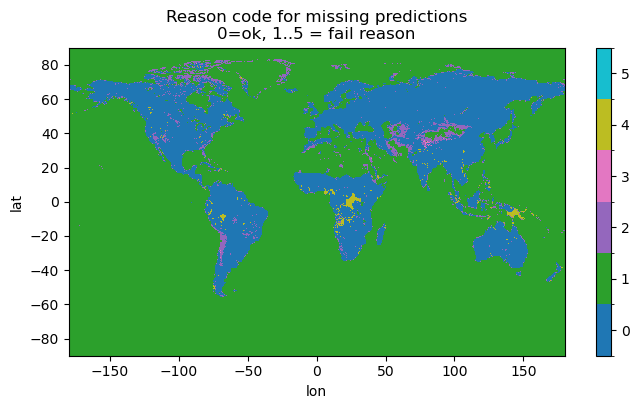

In [7]:
import matplotlib.pyplot as plt
reason_da = xr.DataArray(
    reason,
    dims=("pix",),
    coords={"pix": lai_v["pix"]}
).unstack("pix")   # back to 2D (lat, lon)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
reason_da.plot(
    cmap="tab10",
    levels=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5],  # boundaries between categories
    add_colorbar=True,
    cbar_kwargs={"ticks": [0, 1, 2, 3, 4, 5]}
)
plt.title("Reason code for missing predictions\n0=ok, 1..5 = fail reason")
plt.show()

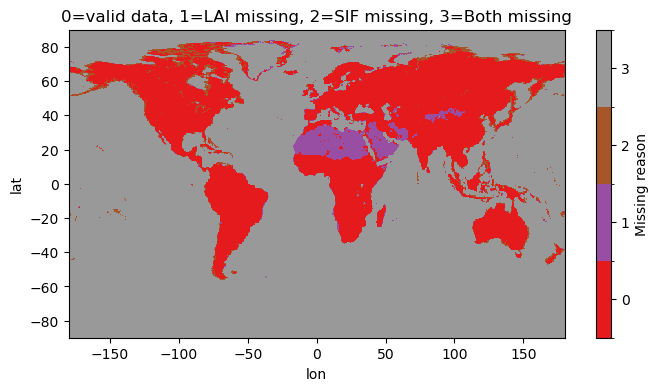

In [8]:
import numpy as np

# count valid (non-NaN) per pixel across time
lai_valid_count = np.sum(np.isfinite(lai_np), axis=0)
sif_valid_count = np.sum(np.isfinite(sif_np), axis=0)

# categorize
miss_map = np.zeros(P, dtype=np.int8)
miss_map[(lai_valid_count == 0) & (sif_valid_count == 0)] = 3  # both missing
miss_map[(lai_valid_count == 0) & (sif_valid_count > 0)] = 1   # LAI missing
miss_map[(lai_valid_count > 0) & (sif_valid_count == 0)] = 2   # SIF missing

# wrap into DataArray (lat, lon)
miss_da = xr.DataArray(
    miss_map,
    dims=("pix",),
    coords={"pix": lai_v["pix"]}
).unstack("pix")

# plot
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
miss_da.plot(
    cmap="Set1",
    levels=[-0.5,0.5,1.5,2.5,3.5],
    cbar_kwargs={"ticks":[0,1,2,3], "label":"Missing reason"}
)
plt.title("0=valid data, 1=LAI missing, 2=SIF missing, 3=Both missing")
plt.show()


In [9]:
# ------------------ GBRT helpers (NA-safe & variance screen) ------------------
def _stratified_subsample(idx, lai_vals, max_n=MAX_TRAIN, bins=20, per_bin=30, rng=np.random.default_rng(42)):
    """Subsample indices stratified across LAI quantiles to preserve dynamic range."""
    if idx.size <= max_n: return idx
    qs = np.quantile(lai_vals[idx], np.linspace(0, 1, bins+1))
    take = []
    for i in range(bins):
        slab = idx[(lai_vals[idx] >= qs[i]) & (lai_vals[idx] < qs[i+1])]
        if slab.size:
            take.append(rng.choice(slab, size=min(per_bin, slab.size), replace=False))
    return np.unique(np.concatenate(take)) if take else idx[:max_n]

def _fit_gbrt_single_pixel(k):
    lai_1d = lai_np[:, k]
    sif_1d = sif_np[:, k]
    gs_1d  = gs_np[:, k]
    dr_1d  = dr_np[:, k]

    # Skip NAs up-front
    valid_all = np.isfinite(lai_1d) & np.isfinite(sif_1d)
    if not np.any(valid_all):
        return k, None, np.nan

    # Non-drought & within GS & valid
    nd_mask = (gs_1d == 1) & (dr_1d == 0) & valid_all
    idx = np.flatnonzero(nd_mask)
    if idx.size < MIN_N_NON_DROUGHT:
        return k, None, np.nan

    # Variance screen
    if np.nanstd(lai_1d[idx]) < 1e-3 or np.nanstd(sif_1d[idx]) < 1e-3:
        return k, None, np.nan

    # Stratified subsample for speed
    idx = _stratified_subsample(idx, lai_1d, max_n=MAX_TRAIN)

    X = lai_1d[idx].reshape(-1, 1)
    y = sif_1d[idx]

    # Time-block split
    n = X.shape[0]
    ntr = max(MIN_N_NON_DROUGHT, int(0.8 * n))
    Xtr, ytr = X[:ntr], y[:ntr]
    Xva, yva = X[ntr:], y[ntr:] if ntr < n else (np.empty((0,1)), np.empty((0,)))

    model = HistGradientBoostingRegressor(**HGB_KW).fit(Xtr, ytr)
    r2 = np.nan
    if Xva.shape[0] > 0:
        try:
            r2 = float(r2_score(yva, model.predict(Xva)))
        except Exception:
            r2 = np.nan
    return k, model, r2

def _predict_drought_gbrt(k, model):
    pred = np.full(T, np.nan, dtype=np.float32)
    if model is None:
        return k, pred
    lai_1d = lai_np[:, k]
    gs_1d  = gs_np[:, k]
    dr_1d  = dr_np[:, k]
    m = (gs_1d == 1) & (dr_1d == 1)
    if not np.any(m):
        return k, pred
    Xd = lai_1d[m].reshape(-1, 1)
    valid = np.isfinite(Xd[:, 0])
    yp = np.full(Xd.shape[0], np.nan, dtype=np.float32)
    if np.any(valid):
        yp[valid] = model.predict(Xd[valid]).astype(np.float32)
    pred[np.where(m)[0]] = yp
    return k, pred


In [10]:
# ------------------ train & predict in small batches (low RAM) ------------------
from joblib import Parallel, delayed, parallel_backend
import gc, numpy as np

sif_pred_mat = np.full((T, P), np.nan, dtype=np.float32)
gbr_r2_vec   = np.full((P,),   np.nan, dtype=np.float32)

done = 0
print_progress(done, P, prefix="Pixels")
with parallel_backend("threading"):   # <-- threads (no temp files)
    for batch in _batches(P, BATCH_PIXELS):
        batch = list(batch)

        # train
        results = Parallel(n_jobs=N_JOBS)(
            delayed(_fit_gbrt_single_pixel)(k) for k in batch
        )

        models = {}
        for k, model, r2 in results:
            models[k] = model
            gbr_r2_vec[k] = r2

        # predict
        preds = Parallel(n_jobs=N_JOBS)(
            delayed(_predict_drought_gbrt)(k, models[k]) for k in batch
        )

        for k, pred in preds:
            sif_pred_mat[:, k] = pred

        done += len(batch)
        print_progress(done, P, prefix="Pixels")

        # hard cleanup
        del results, models, preds
        gc.collect()
print()  # newline after progress bar

Pixels [########----------------------] 74000/259200 ( 28.5%)

C:\Users\DELL\miniconda3\envs\geo_advanced\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


Pixels [#########---------------------] 80000/259200 ( 30.9%)

C:\Users\DELL\miniconda3\envs\geo_advanced\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


Pixels [#########---------------------] 84000/259200 ( 32.4%)

...

Pixels [######################--------] 196000/259200 ( 75.6%)

C:\Users\DELL\miniconda3\envs\geo_advanced\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\DELL\miniconda3\envs\geo_advanced\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\DELL\miniconda3\envs\geo_advanced\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\DELL\miniconda3\envs\geo_advanced\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


Pixels [######################--------] 198000/259200 ( 76.4%)

C:\Users\DELL\miniconda3\envs\geo_advanced\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


Pixels [##############################] 259200/259200 (100.0%)


In [11]:
# ------------------ assemble outputs & write ------------------
sif_pred = xr.DataArray(sif_pred_mat, coords={"time": lai_v.time, "pix": lai_v.pix},
                        dims=("time","pix"), name="SIF_pred").unstack("pix")

sifratio = sif.copy(deep=True).astype(np.float32)
sifratio.values[:] = np.nan
drought_bool = ((gs == 1) & (dr == 1)).values
sifratio.values[drought_bool] = sif.values[drought_bool] - sif_pred.values[drought_bool]
sifratio.name = "SIFratio"

gbr_r2 = xr.DataArray(gbr_r2_vec, coords={"pix": lai_v.pix}, dims=("pix",), name="gbr_r2").unstack("pix")

# Metadata & write
sif_pred.attrs["long_name"] = "Predicted SIF during drought via GBRT(SIF~LAI) trained on non-drought months within GS"
sifratio.attrs["long_name"] = "SIF_drought − SIF_pred (negative = drought loss conditional on LAI)"
gbr_r2.attrs["long_name"]   = "Validation R² on held-out non-drought block (per pixel)"

comp = dict(zlib=True, complevel=4)
enc = {"SIF_pred": {"_FillValue": np.float32(np.nan), **comp},
       "SIFratio": {"_FillValue": np.float32(np.nan), **comp},
       "gbr_r2":   {"_FillValue": np.float32(np.nan), **comp}}
xr.Dataset({"SIF_pred": sif_pred, "SIFratio": sifratio, "gbr_r2": gbr_r2}).to_netcdf(OUT_NC, encoding=enc)
print("[OK] wrote:", OUT_NC)

[OK] wrote: c:/proj9/sifratio_8day_gbrt.nc
